# <h2 style='color:blue' align='center'>**Chest X-Ray Pneumonia Classification: Scratch CNN** 🫁</h2>

### **CAP 4630 - Intro to Artificial Intelligence | Final Project**

**Team Member:** Alexander Moller

**Dataset:** [Chest X-Ray Pneumonia Balanced Dataset](https://www.kaggle.com/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/data)

**Split:** 80% Train | 10% Validation | 10% Test

<div style="border-radius:12px; padding: 20px; background-color: #e2c9ff; font-size:115%; text-align:left">

<h2 align="left"><font color=#8502d1>About the Project</font></h2>

We classify chest X-ray images into two classes:

- **NORMAL** 🟢 — Healthy lungs
- **PNEUMONIA** 🔴 — Lungs showing pneumonia infection

We compare **Three iteration approaches**:

1. **Model 1: Scratch CNN** — A Sequential CNN with Conv2D, MaxPooling2D, Dense, and Sigmoid activation layer. Establishing a baseline model to identify performance

2. **Model 2: Scratch CNN with Data Augmentation** — A Sequential CNN similar to Model 1, addressing issues such as overfitting, through adding data augmentation with random transformations (rotation, width/height shifts, and horizontal flips).

3. **Model 3: Scratch CNN with Data Augmentation & Batch Normilization** - Advanced approach from Model 2, to improve stablility, adding batch normilization, increasing Dropout rate: 0.2 -> 0.5, and a reduced learning rate on plateau when the validation loss stops improving

</div>

<h4 style="color:purple">Step 1: Mount Google Drive & Unzip the Dataset 📂</h4>

In [74]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/final_dataset_80_10_10.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/xray_data')

dataset = '/content/xray_data/final_dataset_80_10_10'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<h4 style="color:purple">Step 2: Import Necessary Libraries ☝️
</h4>

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Activation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
import os

<h4 style="color:purple"> Step 3: Define Standard Helper functions 🛠️<h4>

In [76]:

def image_plt(images, labels):
  plt.figure(figsize = (15,8))
  for i in range(1,11):
    plt.subplot(2, 5, i)
    plt.imshow(images[i-1])
    plt.title('Label: ' + str(labels[i-1]))
    plt.show()

def accuracy_function(labels_actual, labels_predicted):
  accuracy = np.sum(labels_actual == labels_predicted) / len(labels_actual) * 100
  return accuracy

def plot_curve(accuracy_train, loss_train, title='Training'):
    epochs = np.arange(loss_train.shape[0])
    plt.subplot(1, 2, 1)
    plt.plot(epochs, accuracy_train)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(title + ' Accuracy')
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss_train)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title + ' Loss')
    plt.show()

<h4 style="color:purple">Step 4: Load & Preprocess Images from Dataset Splits 🗃️
</h4>

Iterate through each class folder and resize images to 224 x 224, and organizing them into NumPy arrays for an 80:10:10 split

In [77]:
from PIL import Image

#224 by 224 image size
IMG_size = (224,224)

#create labels
classes = np.array(['NORMAL', 'PNEUMONIA'])

def load_split(split):
    images, labels = [], []
    for label, class_name in enumerate(classes):
        class_path = os.path.join(dataset, split, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path).convert('RGB').resize(IMG_size)
                images.append(np.array(img))
                labels.append(label)
            except:
                pass
    return np.array(images), np.array(labels)

#load split from subfolders
x_train, y_train = load_split('train')
x_val,   y_val   = load_split('val')
x_test,  y_test  = load_split('test')

<h4 style="color:purple">Step 5: Identify Specifics of Dataset Splits 🗃️
</h4>

In [78]:
#identify shape of segments in a 80:10:10 split
print(f"Training shape (80%): ", {x_train.shape})
print(f"Validation Shape (10%): ", {x_val.shape})
print(f"Testing Shape (10%): ", {x_test.shape})

Training shape (80%):  {(6824, 224, 224, 3)}
Validation Shape (10%):  {(852, 224, 224, 3)}
Testing Shape (10%):  {(854, 224, 224, 3)}


<h4 style="color:purple">Step 6: Shuffle, Visualize & Scale Training Data 🎲</h4>

Randomly shuffles the training set and scaling all values to [0,1], then converting labels to encoded binary matrices.

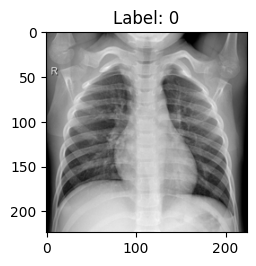

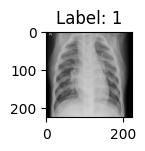

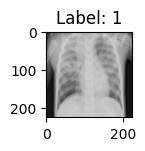

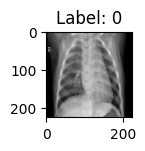

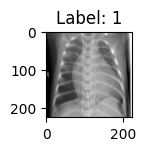

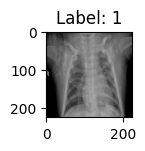

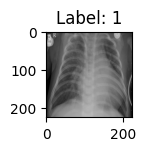

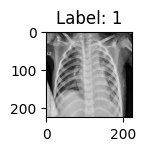

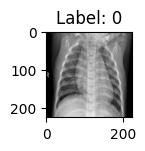

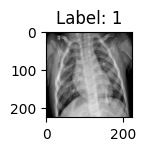

In [79]:
#shuffle training indicies and scale data
num_train_img = x_train.shape[0]
train_ind_s = np.random.permutation(num_train_img)
x_train = x_train[train_ind_s]
y_train = y_train[train_ind_s]

#load first ten images with labels
image_plt(x_train[0:10], y_train[0:10])

#scale images
x_train = x_train.astype('float32') / 255
x_val   = x_val.astype('float32') / 255
x_test  = x_test.astype('float32') / 255

#binary class matrixes
y_train_c = to_categorical(y_train, 2)
y_val_c   = to_categorical(y_val, 2)
y_test_c  = to_categorical(y_test, 2)

#<h2 style='color:#1976d2'>**Part 1: Baseline CNN** 📂</h2>

<h4 style="color:purple">Step 7: Model 1 — Baseline Scratch CNN Training & Performance 📊</h4>

Creating and training a scratch CNN model using two convolutional layers, 128-unit dense layer, and a sigmoid activation layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    25,690,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,755,937 (98.25 MB)

 Trainable params: 25,755,937 (98.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - acc: 0.8469 - loss: 0.7473
Epoch 1: val_loss improved from None to 0.15294, saving model to /content/drive/MyDrive/model_a_XRAY1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/model_a_XRAY1.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 31s 127ms/step - acc: 0.9157 - loss: 0.2958 - val_acc: 0.9554 - val_loss: 0.1529
Epoch 2/50
213/214 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - acc: 0.9679 - loss: 0.0977
Epoch 2: val_loss improved from 0.15294 to 0.09591, saving model to /content/drive/MyDrive/model_a_XRAY1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/model_a_XRAY1.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 24s 110ms/step - acc: 0.9628 - loss: 0.1045 - val_acc: 0.9742 - val_loss: 0.0959
Epoch 3/50
213/214 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - acc: 0.9702 - loss: 0.0831
Epoch 3: val_loss did not improve from 0.09591
214/214 ━━━━━━━━━━━━━━━━━━━━ 22s 105ms/step - acc: 0.9685 - loss: 0.0876 - val_acc: 0.9718 - val_loss: 0.0966

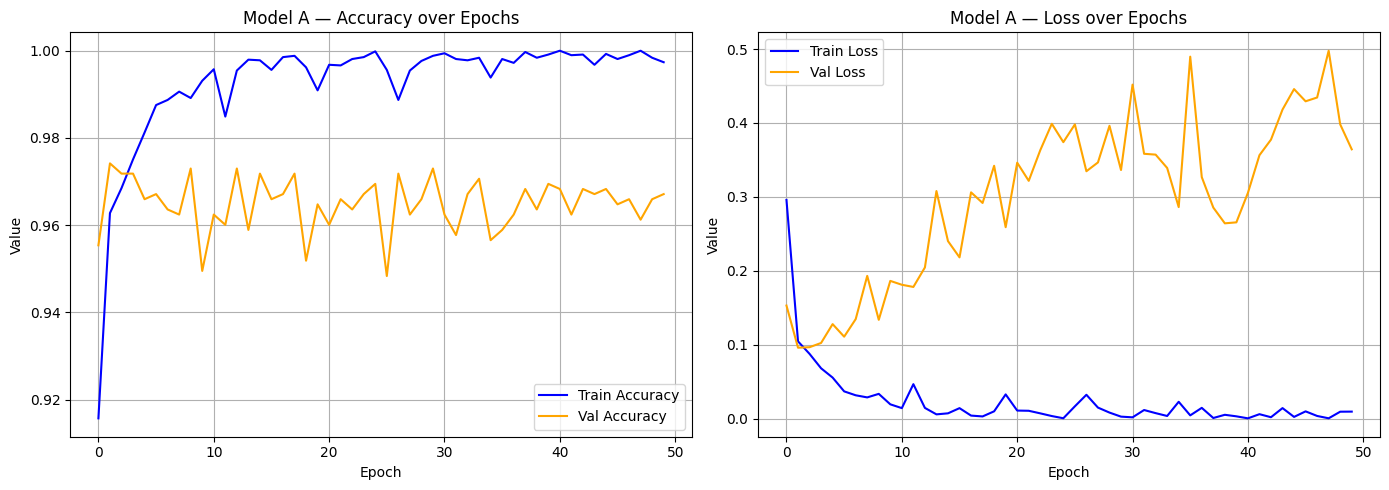

In [80]:
#defining model #1

from keras.callbacks import ModelCheckpoint

#layer 1
model_a = Sequential()
model_a.add(Conv2D(32, (3, 3), padding = 'same', input_shape = x_train.shape[1:]))
model_a.add(Activation('relu'))
model_a.add(Conv2D(32, (3, 3), padding = 'same'))
model_a.add(Activation('relu'))
model_a.add(MaxPooling2D(pool_size=(2, 2)))
#layer 2
model_a.add(Conv2D(64, (3, 3), padding = 'same'))
model_a.add(Activation('relu'))
model_a.add(Conv2D(64, (3, 3), padding = 'same'))
model_a.add(Activation('relu'))
model_a.add(MaxPooling2D(pool_size = (2,2)))

#flatten
model_a.add(Flatten())
model_a.add(Dense(128))
model_a.add(Dropout(0.5))
model_a.add(Dense(1))
model_a.add(Activation('sigmoid'))

#summary
model_a.summary()

#create model checkpoint
save_path = '/content/drive/MyDrive/model_a_XRAY1.keras'
callbacks_save = ModelCheckpoint(save_path, monitor = 'val_loss', verbose = 1, save_best_only = True, save_freq = 'epoch')

#model
opt = tf.keras.optimizers.Adam(learning_rate = 0.001)
model_a.compile(loss = 'binary_crossentropy', optimizer = opt, metrics = ['acc'])

history = model_a.fit(x_train, y_train,
                      batch_size = 32,
                      epochs = 50,
                      verbose = 1,
                      validation_data = (x_val, y_val),
                      callbacks = [callbacks_save])

history_data = history.history
epochs = np.arange(len(history_data['acc']))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history_data['acc'], color='blue', label='Train Accuracy')
plt.plot(epochs, history_data['val_acc'], color='orange', label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model A — Accuracy over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, history_data['loss'], color='blue', label='Train Loss')
plt.plot(epochs, history_data['val_loss'], color='orange', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model A — Loss over Epochs')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

<h4 style="color:purple">Step 8: Model 1 — Evaluate the Model 📉</h4>

In [81]:
scorea = model_a.evaluate(x_test, y_test)
print('Total loss on test set: ', scorea[0])
print('Accuracy of test set: ', scorea[1])

score = model_a.evaluate(x_val, y_val)
print('Total loss on validation set: ', score[0])
print('Accuracy of validation set: ', score[1])

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - acc: 0.9543 - loss: 0.3856
Total loss on test set:  0.38559985160827637
Accuracy of test set:  0.9543325304985046
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9671 - loss: 0.3643
Total loss on validation set:  0.36432698369026184
Accuracy of validation set:  0.9671361446380615


<h4 style="color:purple">Step 9: Model 1 — Confusion Matrix, Accuracy, F1, Precision & Recall Scores ✅</h4>

Generates performance on the test set, with a threshold of 50%, and evaluates Model 1's classification using a confusion matrix, accuracy score, and a classification report that displays: precision, recall, f1-score, and support scores


27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step

The accuracy using the testing set:  0.9543325526932084

The confusion matrix using testing set: 
 [[406  18]
 [ 21 409]]


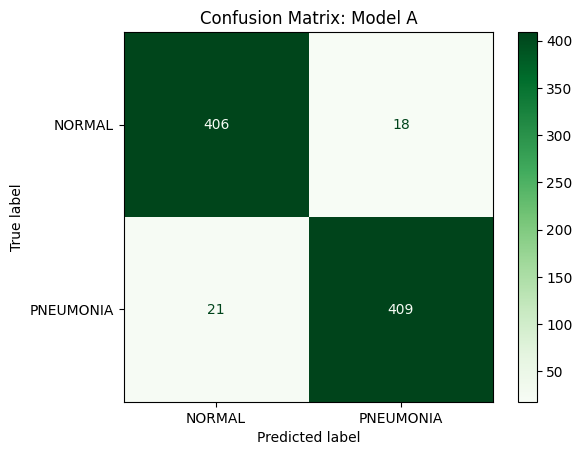


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.95      0.95       427
   PNEUMONIA       0.95      0.96      0.95       427

    accuracy                           0.95       854
   macro avg       0.95      0.95      0.95       854
weighted avg       0.95      0.95      0.95       854



In [82]:
#Defining confusion matrix, F1 score and recall for model 1

test_class1_prob = model_a.predict(x_test)

test_lab = (test_class1_prob > 0.5).astype("int32")


print('\nThe accuracy using the testing set: ', accuracy_score(test_lab,y_test))

conf_matx =confusion_matrix(test_lab,y_test)
print('\nThe confusion matrix using testing set: \n', conf_matx)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matx, display_labels=classes)
disp.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix: Model A')
plt.show()

#F1, Recall, Precision
print('\nClassification Report:')
print(classification_report(y_test, test_lab, target_names=classes))

<h4 style="color:purple">Step 10: Model 1 — Receiver Operating Characteristic (ROC) Curve </h4>

Plots the true positive rate against the false positive rate accross the threshold to determine model capability


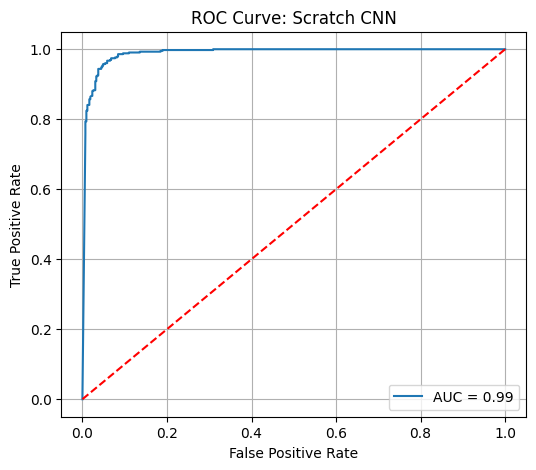

In [83]:
#model a
fpr_a, tpr_a, _ = roc_curve(y_test, test_class1_prob)
auc_a = auc(fpr_a, tpr_a)
plt.figure(figsize=(6, 5))
plt.plot(fpr_a, tpr_a, label=f'AUC = {auc_a:.2f}')
plt.plot([0, 1], [0, 1], color = 'r', linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Scratch CNN')
plt.legend()
plt.grid(True)
plt.show()


#<h2 style='color:#1976d2'>**Part 2: CNN + Data Augmentation** 📝</h2>

<h4 style="color:purple">Step 11: Model 2 — Scratch CNN + Data Augmenation Training & Performance 🔎</h4>

Creating and training a scratch CNN model using two convolutional layers, 128-unit dense layer, and a sigmoid activation layer.

**Note:** The previous model showed signs of overfitting the data, so I added data augmentation to train the model on more similar images with rotation, width/height shifting, and horizontal flips.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    25,690,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,755,937 (98.25 MB)

 Trainable params: 25,755,937 (98.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - acc: 0.7540 - loss: 1.2261
Epoch 1: val_loss improved from None to 0.19876, saving model to /content/drive/MyDrive/model_b_XRAY2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/model_b_XRAY2.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 74s 330ms/step - acc: 0.8509 - loss: 0.5096 - val_acc: 0.9296 - val_loss: 0.1988
Epoch 2/50
  1/213 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - acc: 1.0000 - loss: 0.0406

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss did not improve from 0.19876
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 1.0000 - loss: 0.0406 - val_acc: 0.9237 - val_loss: 0.2117
Epoch 3/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - acc: 0.9126 - loss: 0.2291
Epoch 3: val_loss improved from 0.19876 to 0.18724, saving model to /content/drive/MyDrive/model_b_XRAY2.keras

Epoch 3: finished saving model to /content/drive/MyDrive/model_b_XRAY2.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 69s 323ms/step - acc: 0.9171 - loss: 0.2172 - val_acc: 0.9319 - val_loss: 0.1872
Epoch 4/50
  1/213 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - acc: 0.9062 - loss: 0.1500
Epoch 4: val_loss did not improve from 0.18724
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9062 - loss: 0.1500 - val_acc: 0.9284 - val_loss: 0.1987
Epoch 5/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - acc: 0.9244 - loss: 0.2051
Epoch 5: val_loss did not improve from 0.18724
213/213 ━━━━━━━━━━━━━━━━━━━━ 68s 320ms/step - acc: 0.9307 - loss: 0.1925 - val_acc: 0.8979 - val

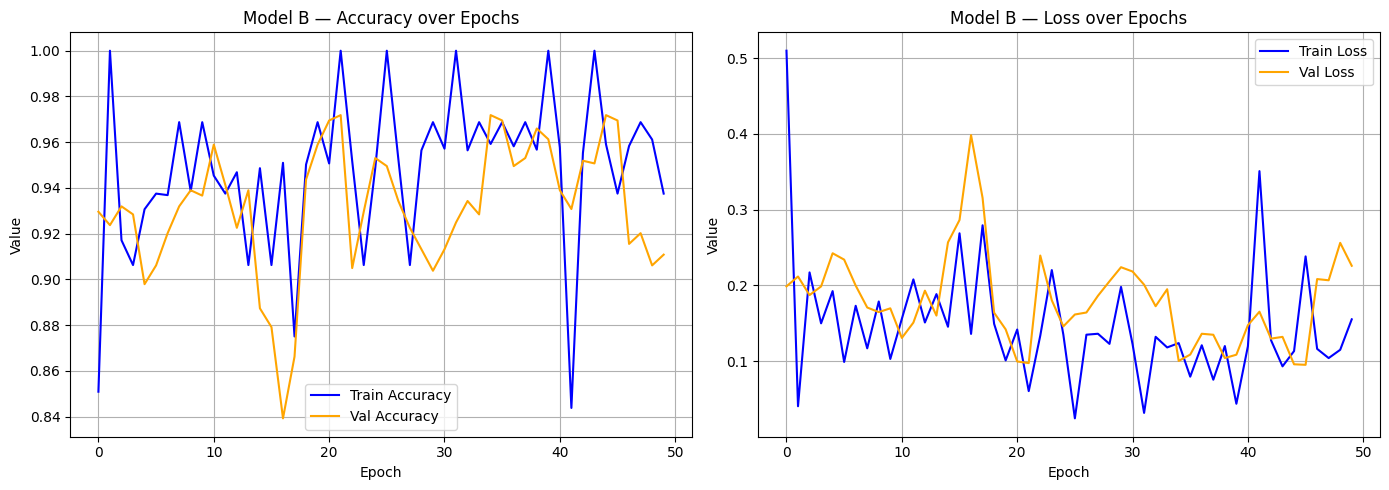

In [84]:
#defining model 2 with augmented images due to reduce overfitting

#layer 1
model_b = Sequential()
model_b.add(Conv2D(32, (3, 3), padding = 'same', input_shape = x_train.shape[1:]))
model_b.add(Activation('relu'))
model_b.add(Conv2D(32, (3, 3), padding = 'same'))
model_b.add(Activation('relu'))
model_b.add(MaxPooling2D(pool_size=(2, 2)))
#layer 2
model_b.add(Conv2D(64, (3, 3), padding = 'same'))
model_b.add(Activation('relu'))
model_b.add(Conv2D(64, (3, 3), padding = 'same'))
model_b.add(Activation('relu'))
model_b.add(MaxPooling2D(pool_size = (2,2)))

#flatten
model_b.add(Flatten())
model_b.add(Dense(128))
model_b.add(Dropout(0.5))
model_b.add(Dense(1))
model_b.add(Activation('sigmoid'))
#summary
model_b.summary()

save_path = '/content/drive/MyDrive/model_b_XRAY2.keras'
callbacks_save = ModelCheckpoint(save_path, monitor = 'val_loss', verbose = 1, save_best_only = True, save_freq = 'epoch')

opt = tf.keras.optimizers.Adam(learning_rate = 0.001)
model_b.compile(loss = 'binary_crossentropy', optimizer = opt, metrics = ['acc'])

train_datagen = ImageDataGenerator(
    rotation_range = 10,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True)

val_datagen = ImageDataGenerator()
train_datagen.fit(x_train)

history_b = model_b.fit(train_datagen.flow(x_train, y_train, batch_size=32),
                      steps_per_epoch=len(x_train) // 32,
                      epochs=50,
                      verbose=1,
                      validation_data=val_datagen.flow(x_val, y_val, batch_size=32),
                      callbacks=[callbacks_save])

history_data = history_b.history
epochs = np.arange(len(history_data['acc']))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history_data['acc'], color='blue', label='Train Accuracy')
plt.plot(epochs, history_data['val_acc'], color='orange', label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model B — Accuracy over Epochs')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_data['loss'], color='blue', label='Train Loss')
plt.plot(epochs, history_data['val_loss'], color='orange', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model B — Loss over Epochs')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()


<h4 style="color:purple">Step 12: Model 2 — Evaluate the Model 📑</h4>

In [85]:
scoreb = model_b.evaluate(x_test, y_test)
print('Total loss on test set: ', scoreb[0])
print('Accuracy of test set: ', scoreb[1])

score = model_b.evaluate(x_val, y_val)
print('Total loss on validation set: ', score[0])
print('Accuracy of validation set: ', score[1])

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - acc: 0.9040 - loss: 0.2325
Total loss on test set:  0.23247872292995453
Accuracy of test set:  0.9039812684059143
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9108 - loss: 0.2259
Total loss on validation set:  0.22590412199497223
Accuracy of validation set:  0.9107981324195862


<h4 style="color:purple">Step 13: Model 2 — Confusion Matrix, Accuracy, F1, Precision & Recall Scores 🎯</h4>

Runs the test set through Model 2 + data augmentation, applies a 50% threshold, and creates a confusion matrix alongside accuracy, precision, recall, and F1-score evaluations.

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step

The accuracy using the testing set:  0.9039812646370023

The confusion matrix using testing set: 
 [[425  80]
 [  2 347]]


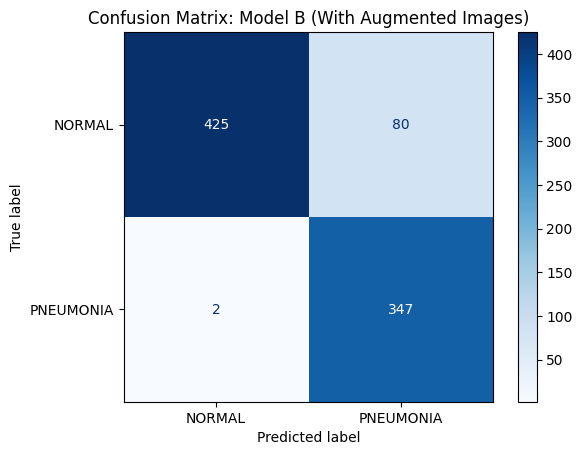


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.84      1.00      0.91       427
   PNEUMONIA       0.99      0.81      0.89       427

    accuracy                           0.90       854
   macro avg       0.92      0.90      0.90       854
weighted avg       0.92      0.90      0.90       854



In [86]:
#Defining confusion matrix, F1 score & recall for model 2

test_class2_prob = model_b.predict(x_test)

test_lab2 = (test_class2_prob > 0.5).astype("int32")


print('\nThe accuracy using the testing set: ', accuracy_score(test_lab2,y_test))

conf_matx =confusion_matrix(test_lab2,y_test)
print('\nThe confusion matrix using testing set: \n', conf_matx)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matx, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: Model B (With Augmented Images)')
plt.show()

#F1, Recall, Precision
print('\nClassification Report:')
print(classification_report(y_test, test_lab2, target_names=classes))

<h4 style="color:purple">Step 14: Model 2 — Receiver Operating Characteristic (ROC) Curve </h4>

Plots the true positive rate against the false positive rate accross the threshold to determine model capability


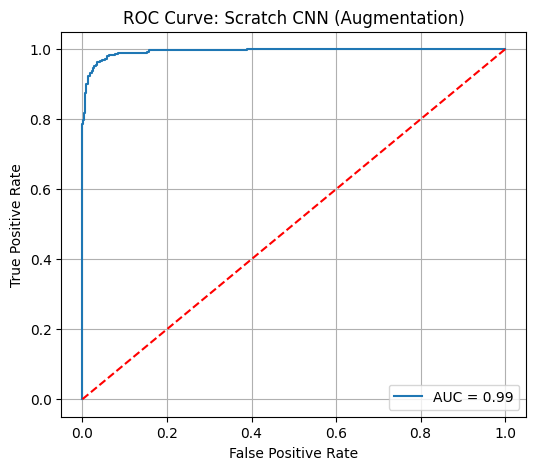

In [87]:
fpr_b, tpr_b, _ = roc_curve(y_test, test_class2_prob)
auc_b = auc(fpr_b, tpr_b)
plt.figure(figsize=(6, 5))
plt.plot(fpr_b, tpr_b, label=f'AUC = {auc_b:.2f}')
plt.plot([0, 1], [0, 1], color = 'r', linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Scratch CNN (Augmentation)')
plt.legend()
plt.grid(True)
plt.show()

#<h2 style='color:#1976d2'>**Part 3: CNN + Data Augmentation, Batch Normilization, & LR Scheduling** 🧠</h2>

<h4 style="color:purple">Step 15: Model 3 — Scratch CNN + Data Augmenation, Batch Normlization, & ReduceLROnPleateu Evaluation 🔧</h4>

Builds a finalized CNN with BatchNormalization after each convolutional layer, increased Dropout rate, and a ReduceLROnPlateau callback which will reduce the learning rate as it comes closer to higher performance, then trains on augmented data and evaluates on validation and test splits

**Note:** The previous model (Model 2) had trouble stablizing and converging towards the end of the iteration of epochs, so there was an adding ReduceLROnPLateau which will reduce the learning rate in adherance to the validation set, as well as an added batch normilization to stabilize the data

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │    25,690,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 25,756,897 (98.25 MB)

 Trainable params: 25,756,257 (98.25 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - acc: 0.8774 - loss: 0.4148
Epoch 1: val_loss improved from None to 4.16696, saving model to /content/drive/MyDrive/model_c_XRAY3.keras

Epoch 1: finished saving model to /content/drive/MyDrive/model_c_XRAY3.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 80s 341ms/step - acc: 0.9043 - loss: 0.2929 - val_acc: 0.5000 - val_loss: 4.1670 - learning_rate: 5.0000e-04
Epoch 2/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - acc: 0.9266 - loss: 0.1865
Epoch 2: val_loss improved from 4.16696 to 0.44474, saving model to /content/drive/MyDrive/model_c_XRAY3.keras

Epoch 2: finished saving model to /content/drive/MyDrive/model_c_XRAY3.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 68s 316ms/step - acc: 0.9282 - loss: 0.1865 - val_acc: 0.7840 - val_loss: 0.4447 - learning_rate: 5.0000e-04
Epoch 3/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - acc: 0.9384 - loss: 0.1594
Epoch 3: val_loss improved from 0.44474 to 0.09855, saving model to /content/drive/MyDrive/model_c_X

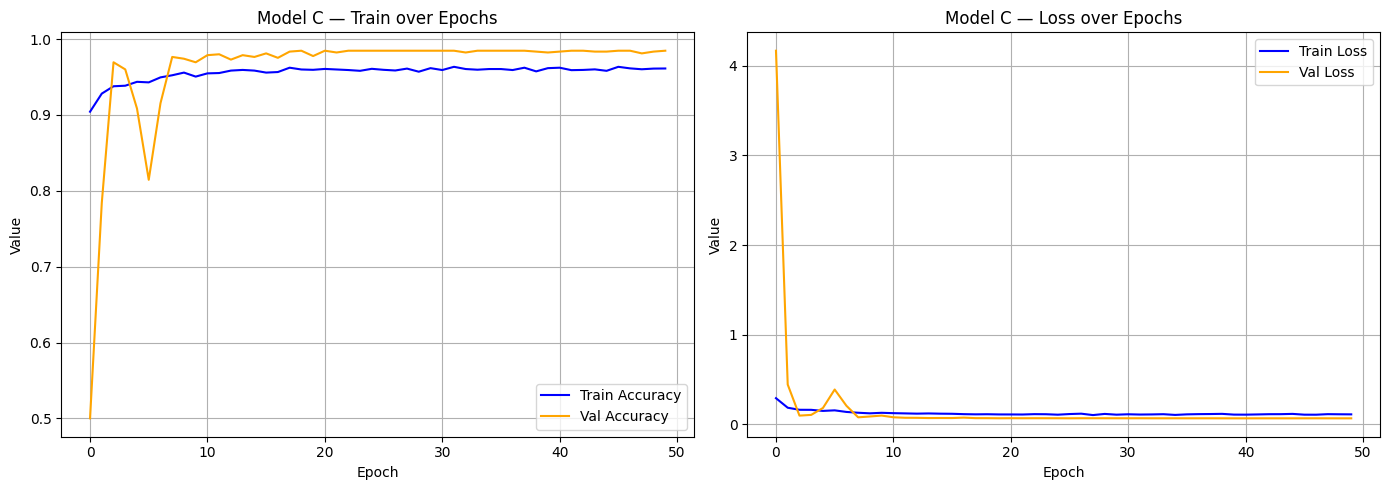

In [88]:
from keras.layers import BatchNormalization
from keras.callbacks import ReduceLROnPlateau

#defining model 3 with batch normilization

reduce_lr = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.2,
    patience = 3,
    min_lr = 0.000001,
    verbose = 1)

#layer 1
model_c = Sequential()
model_c.add(Conv2D(32, (3, 3), padding = 'same', use_bias=False, input_shape = x_train.shape[1:]))
model_c.add(BatchNormalization())
model_c.add(Activation('relu'))
model_c.add(Conv2D(32, (3, 3), padding = 'same', use_bias=False))
model_c.add(BatchNormalization())
model_c.add(Activation('relu'))
model_c.add(MaxPooling2D(pool_size=(2, 2)))
model_c.add(Dropout(0.2))

#layer 2
model_c.add(Conv2D(64, (3, 3), padding = 'same', use_bias=False))
model_c.add(BatchNormalization())
model_c.add(Activation('relu'))
model_c.add(Conv2D(64, (3, 3), padding = 'same', use_bias=False))
model_c.add(BatchNormalization())
model_c.add(Activation('relu'))
model_c.add(MaxPooling2D(pool_size = (2,2)))
model_c.add(Dropout(0.2))

#flatten
model_c.add(Flatten())
model_c.add(Dense(128, use_bias = False))
model_c.add(BatchNormalization())
model_c.add(Dropout(0.5))
model_c.add(Dense(1))
model_c.add(Activation('sigmoid'))
#summary
model_c.summary()

save_path = '/content/drive/MyDrive/model_c_XRAY3.keras'
callbacks_save = ModelCheckpoint(save_path, monitor = 'val_loss', verbose = 1, save_best_only = True, save_freq = 'epoch')

opt = tf.keras.optimizers.Adam(learning_rate = 0.0005)
model_c.compile(loss = 'binary_crossentropy', optimizer = opt, metrics = ['acc'])

history_c = model_c.fit(train_datagen.flow(x_train, y_train, batch_size=32),
                      epochs=50,
                      verbose=1,
                      validation_data=val_datagen.flow(x_val, y_val, batch_size=32),
                      callbacks=[callbacks_save, reduce_lr])

history_data = history_c.history
epochs = np.arange(len(history_data['acc']))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history_data['acc'], color='blue', label='Train Accuracy')
plt.plot(epochs, history_data['val_acc'], color='orange', label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model C — Train over Epochs')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_data['loss'], color='blue', label='Train Loss')
plt.plot(epochs, history_data['val_loss'], color='orange', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model C — Loss over Epochs')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()


<h4 style="color:purple">Step 16: Model 3 — Evaluate the Model 📋</h4>

In [89]:
scorec = model_c.evaluate(x_test, y_test)
print('Total loss on test set: ', scorec[0])
print('Accuracy of test set: ', scorec[1])

score = model_c.evaluate(x_val, y_val)
print('Total loss on validation set: ', score[0])
print('Accuracy of validation set: ', score[1])

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - acc: 0.9707 - loss: 0.1016
Total loss on test set:  0.10155053436756134
Accuracy of test set:  0.9707260131835938
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9847 - loss: 0.0684
Total loss on validation set:  0.0683537945151329
Accuracy of validation set:  0.9847418069839478


<h4 style="color:purple">Step 17: Model 3 — Confusion Matrix, Accuracy, F1, Precision & Recall Scores 🎯</h4>

Assesses the batch normalization and adaptive learning rate scheduling evaluation if it further improved the NORMAL vs PNEUMONIA classification by comparing Model 3's confusion matrix and report with Model 1 and 2.



27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step

The accuracy using the testing set:  0.9707259953161592

The confusion matrix using testing set: 
 [[413  11]
 [ 14 416]]


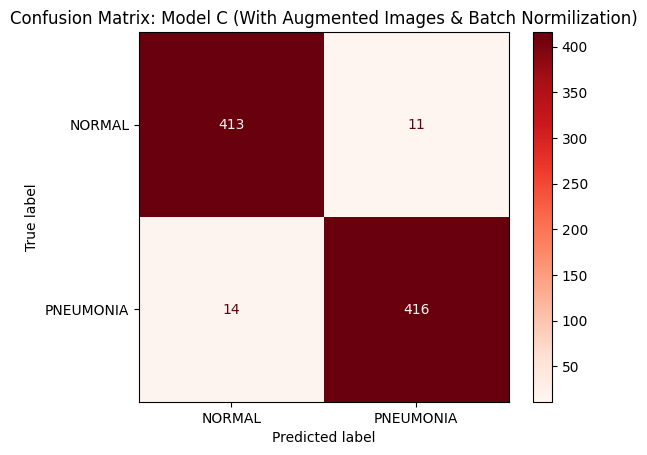


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.97      0.97       427
   PNEUMONIA       0.97      0.97      0.97       427

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



In [90]:
#Defining confusion matrix, F1 score & recall for model 3

test_class3_prob = model_c.predict(x_test)

test_lab3 = (test_class3_prob > 0.5).astype("int32")


print('\nThe accuracy using the testing set: ', accuracy_score(test_lab3,y_test))

conf_matx = confusion_matrix(test_lab3, y_test)
print('\nThe confusion matrix using testing set: \n', conf_matx)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matx, display_labels=classes)
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix: Model C (With Augmented Images & Batch Normilization)')
plt.show()

#F1, Recall, Precision
print('\nClassification Report:')
print(classification_report(y_test, test_lab3, target_names=classes))

<h4 style="color:purple">Step 18: Model 3 — Receiver Operating Characteristic (ROC) Curve </h4>

Plots the true positive rate against the false positive rate accross the threshold to determine model capability


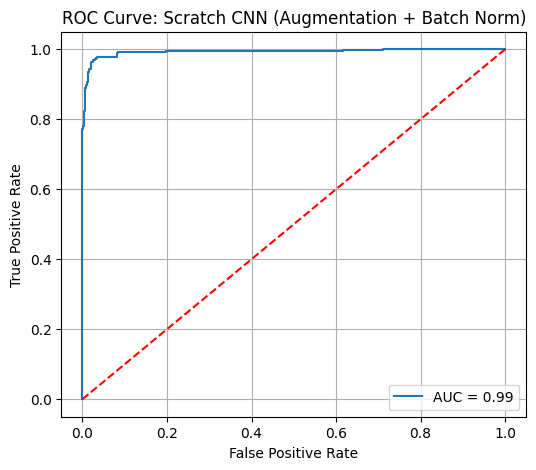

In [91]:
fpr_c, tpr_c, _ = roc_curve(y_test, test_class3_prob)
auc_c = auc(fpr_c, tpr_c)
plt.figure(figsize=(6, 5))
plt.plot(fpr_c, tpr_c, label=f'AUC = {auc_c:.2f}')
plt.plot([0, 1], [0, 1], color = 'r', linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Scratch CNN (Augmentation + Batch Norm)')
plt.legend()
plt.grid(True)
plt.show()

#<h2 style='color:#1976d2'>**Part 4: Comparing Metrics** </h2>

Step 19: Compare scratch CNN vs Iterations based on metrics to determine most efficient model from evaluations.

In [92]:
results = {
    'Model': ['Scratch CNN', 'Scratch CNN (Data Augmentation)', 'Scratch CNN (Data Augmentation + Batch Normilization)'],
    'Accuracy':  [accuracy_score(y_test, test_lab),  accuracy_score(y_test, test_lab2), accuracy_score(y_test, test_lab3)],
    'Precision': [precision_score(y_test, test_lab), precision_score(y_test, test_lab2), precision_score(y_test, test_lab3)],
    'Recall':    [recall_score(y_test, test_lab),    recall_score(y_test, test_lab2), recall_score(y_test, test_lab3)],
    'F1 Score':  [f1_score(y_test, test_lab),        f1_score(y_test, test_lab2), f1_score(y_test, test_lab3)]
}

results_df = pd.DataFrame(results)
print("\nModel Metrics")
print(results_df.to_string(index=False))



Model Metrics
                                                Model  Accuracy  Precision   Recall  F1 Score
                                          Scratch CNN  0.954333   0.951163 0.957845  0.954492
                      Scratch CNN (Data Augmentation)  0.903981   0.994269 0.812646  0.894330
Scratch CNN (Data Augmentation + Batch Normilization)  0.970726   0.967442 0.974239  0.970828


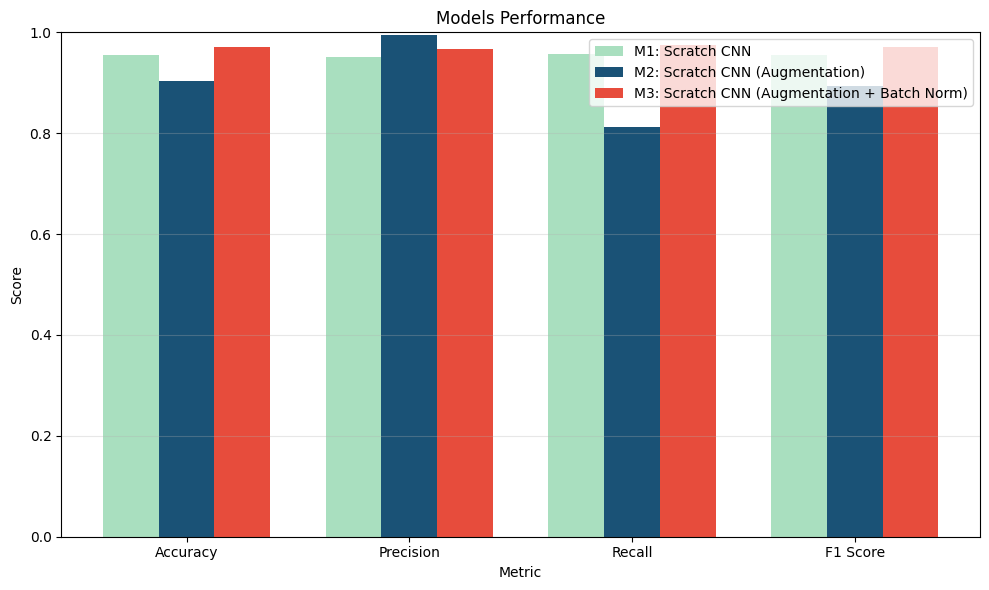

In [93]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores_a = [results[m][0] for m in metrics]
scores_b = [results[m][1] for m in metrics]
scores_c = [results[m][2] for m in metrics]

x = np.arange(len(metrics))
w = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - w, scores_a, w, label='M1: Scratch CNN', color='#a9dfbf')
plt.bar(x, scores_b, w, label='M2: Scratch CNN (Augmentation)', color='#1a5276')
plt.bar(x + w, scores_c, w, label='M3: Scratch CNN (Augmentation + Batch Norm)', color='#e74c3c')

plt.xlabel('Metric')
plt.ylabel('Score')
plt.title('Models Performance')
plt.xticks(x, metrics)
plt.ylim(0, 1.00)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


<div style="border-radius:12px; padding: 20px; background-color: #d4edda; font-size:115%; text-align:left">

#<h2 style='color:#1976d2'>**Part 5: Conclusion 🔍** </h2>

**Step 20: Model iterations evaluation**


This project explored three iterations of convolutional nueral networks (CNN) and trained models on medical X-ray images to detect signs of pnuemonia. Such metrics were evaluated on accuracy, precision, recall, and F1 score.
Overall, the evaluations demonstrate that combining data augmentation with batch normalization produces the highest suitable CNN architecture for pneumonia classification from frontal chest X-ray images with a consistent score of %97 across all metrics. Future work may explore transfer learning approaches as well as updating to multiple classes.

</div>